В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Посилання на файл `process_bank_churn.py` у репозиторії GitHub: https://github.com/mega-herz/python-homeworks/blob/main/process_bank_churn.py

In [429]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.tree import plot_tree, export_text

In [430]:
import importlib
import process_bank_churn

importlib.reload(process_bank_churn)

<module 'process_bank_churn' from '/content/process_bank_churn.py'>

In [431]:
from process_bank_churn import preprocess_data, preprocess_new_data

In [432]:
raw_df = pd.read_csv('train.csv')

In [433]:
data = preprocess_data(raw_df)

In [434]:
X_train = data['X_train']
train_targets = data['train_targets']
X_val = data['X_val']
val_targets = data['val_targets']

In [435]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,696.0,32.0,5.0,130627.66,1.0,1.0,1.0,86786.41,1.0,0.0,0.0,0.0,1.0
14199,632.0,32.0,4.0,119825.75,1.0,1.0,0.0,177737.04,0.0,1.0,0.0,1.0,0.0
1856,679.0,22.0,4.0,0.00,2.0,1.0,1.0,162599.54,1.0,0.0,0.0,1.0,0.0
3013,705.0,48.0,3.0,0.00,2.0,1.0,0.0,119814.25,1.0,0.0,0.0,0.0,1.0
8266,696.0,35.0,7.0,0.00,2.0,1.0,0.0,100423.88,1.0,0.0,0.0,1.0,0.0


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [436]:
# tree instance
model = DecisionTreeClassifier(random_state=42)

In [437]:
# train the model
model.fit(X_train, train_targets)

DecisionTreeClassifier(random_state=42)

In [438]:
# make predictions for train data
train_predicted = model.predict(X_train)
train_probabilities = model.predict_proba(X_train)

In [439]:
# make predictions validation data
val_predicted = model.predict(X_val)
val_probabilities = model.predict_proba(X_val)

In [440]:
def compute_auroc_and_build_roc(targets, probabilities, name=''):
  # Predict probabilities
  #y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve (Receiver Operating Characteristic curve)
  fpr, tpr, thresholds = roc_curve(targets, probabilities)
    # Compute AUROC (ara under the ROC curve)
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.5f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.5f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

In [441]:
def compute_auroc(targets, probabilities, name=''):
  # Compute ROC curve (Receiver Operating Characteristic curve)
  fpr, tpr, thresholds = roc_curve(targets, probabilities)
  # Compute AUROC (ara under the ROC curve)
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.5f}')

  return roc_auc

In [442]:
# calculate AUROC and build ROC-curve for train data
compute_auroc(train_targets, train_probabilities[:,1], 'Training dataset');

AUROC for Training dataset: 1.00000


AUROC for Validation dataset: 0.76312


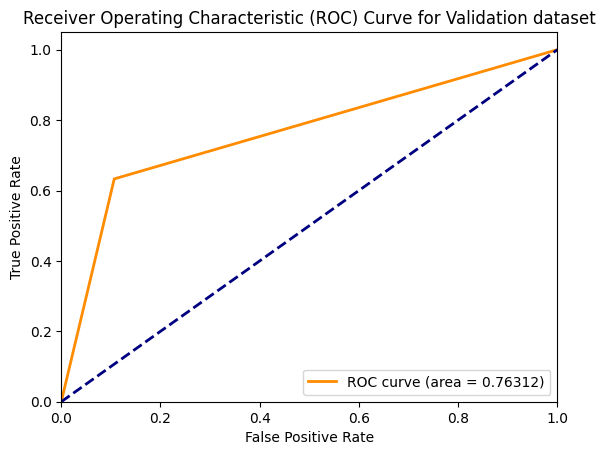

In [443]:
# calculate AUROC and build ROC-curve for validation data
compute_auroc_and_build_roc(val_targets, val_probabilities[:,1], 'Validation dataset')

**Висновок**: Модель має всі ознаки перетренування.



In [444]:
# max depth of the tree model
model.tree_.max_depth

25

In [445]:
# number of leaves
model.tree_.n_leaves

np.int64(1225)

In [446]:
# number of rows (num. of observations) - to compare with num. of leaves
X_train.shape

(11250, 13)

In [447]:
# model of the depth=2
model_depth2 = DecisionTreeClassifier(max_depth=2, random_state=42)

model_depth2.fit(X_train, train_targets)

train_depth2_predicted = model_depth2.predict(X_train)
train_depth2_probabilities = model_depth2.predict_proba(X_train)

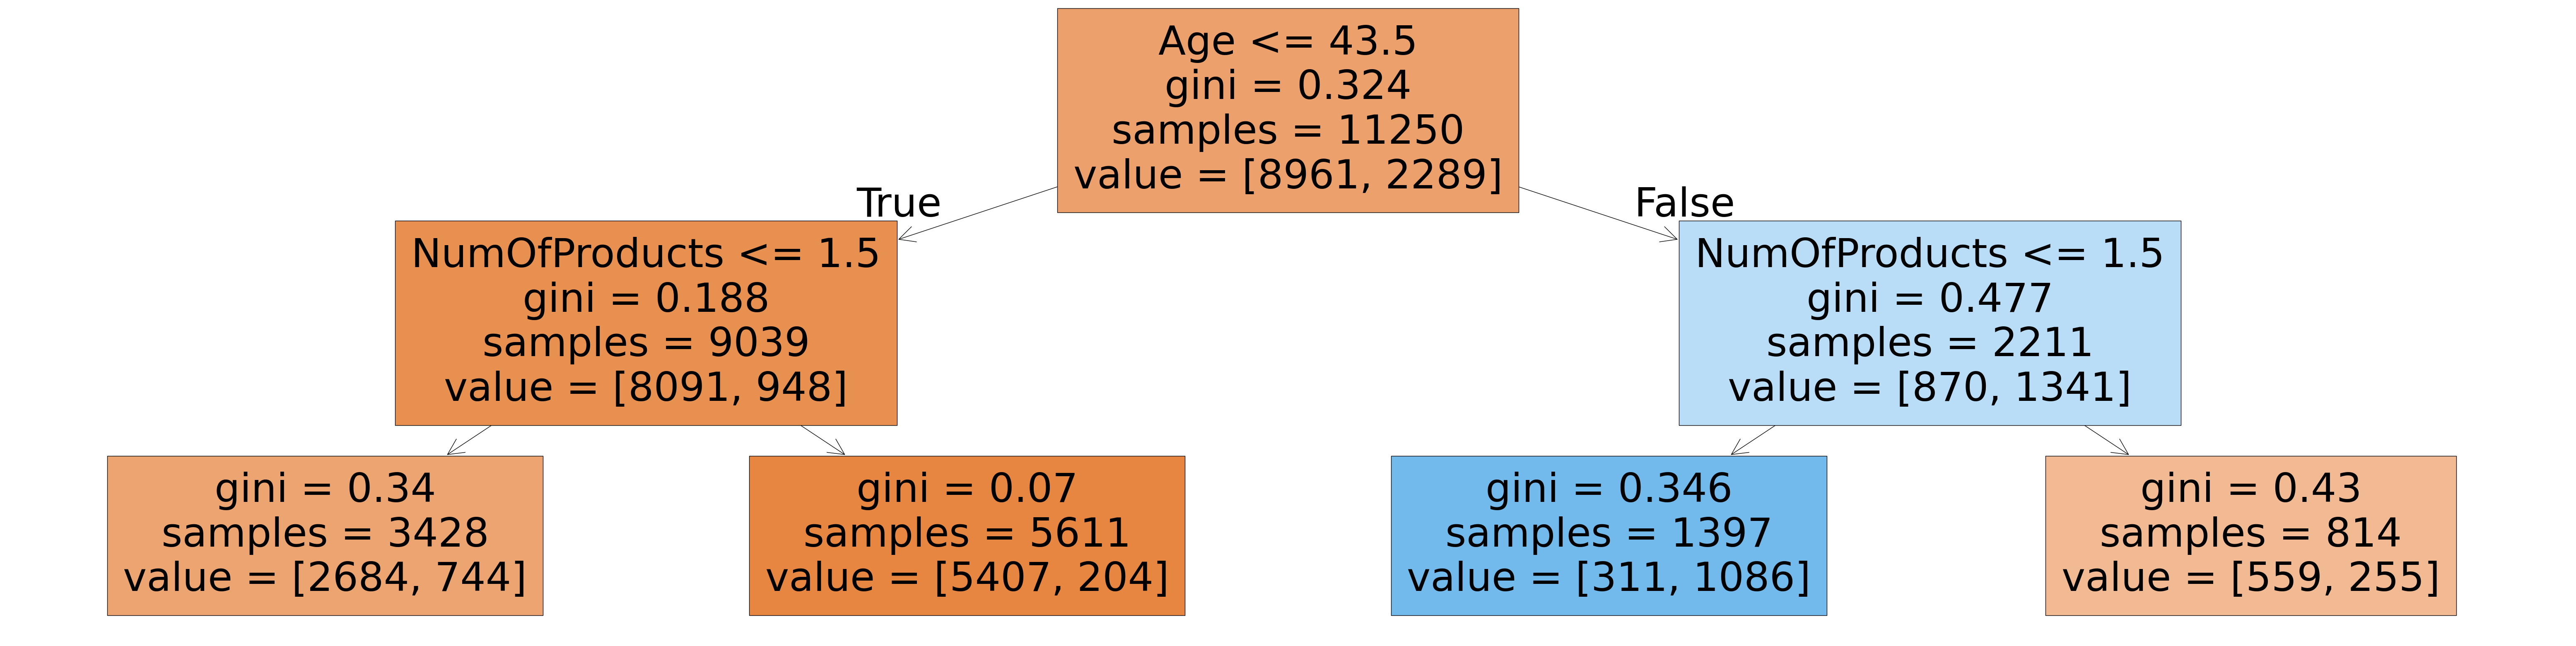

In [448]:
plt.figure(figsize=(80,20))
plot_tree(model_depth2, feature_names=X_train.columns, filled=True);

**Висновок**: дана модель визначила дві найвпливовіші ознаки `Age` та `NumOfProducts`.

In [449]:
# dataframe containing features and their calculated importance for initial model(!) (max_depth not limited)
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [450]:
importance_df.head(10)

,feature,importance
1,Age,0.346301
4,NumOfProducts,0.167947
7,EstimatedSalary,0.131605
0,CreditScore,0.117156
3,Balance,0.081201
2,Tenure,0.061639
6,IsActiveMember,0.033070
9,Geography_Germany,0.015503
5,HasCrCard,0.014113
11,Gender_Female,0.009814


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [451]:
X_train.shape

(11250, 13)

In [452]:
leaves = 54

In [453]:
depth = 7

In [454]:
# model for trying different settings of max_depth and max_leaf_nodes
model_depth_leaves = DecisionTreeClassifier(max_depth=depth, random_state=42, max_leaf_nodes=leaves)

model_depth_leaves.fit(X_train, train_targets)

# prediction for train data
train_depth_leaves_predicted = model_depth_leaves.predict(X_train)
train_depth_leaves_probabilities = model_depth_leaves.predict_proba(X_train)

# prediction for test data
val_depth_leaves_predicted = model_depth_leaves.predict(X_val)
val_depth_leaves_probabilities = model_depth_leaves.predict_proba(X_val)

In [455]:
# calculate AUROC for train data
compute_auroc(train_targets, train_depth_leaves_probabilities[:,1], 'Training dataset');

AUROC for Training dataset: 0.93179


In [456]:
# calculate AUROC for validation data
compute_auroc(val_targets, val_depth_leaves_probabilities[:,1], 'Validation dataset');

AUROC for Validation dataset: 0.92353


**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [457]:
# function to test settings: 1. train model, 2. predict, 3. calculate metric (AUROC)
def max_depth_auroc(X_train, y_train, X_val, y_val, depth):

    # setup and train model
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    # predict probabilities for train and validation data
    probs_train = model.predict_proba(X_train)
    probs_val = model.predict_proba(X_val)

    # Compute ROC curve for train and validation data
    fpr_train, tpr_train, _ = roc_curve(y_train, probs_train[:,1])
    fpr_val, tpr_val, _ = roc_curve(y_val, probs_val[:,1])

    # Compute AUROC for train and test data
    roc_auc_train = auc(fpr_train, tpr_train)
    roc_auc_val = auc(fpr_val, tpr_val)

    return {'Max depth': depth, 'AUROC train': roc_auc_train, 'AUROC validation': roc_auc_val}

In [458]:
# datafarme with AUROC values for train and validation data for the range of max. tree depth
auroc_df = pd.DataFrame([max_depth_auroc(X_train, train_targets, X_val, val_targets, depth) for depth in range(1, 21)])

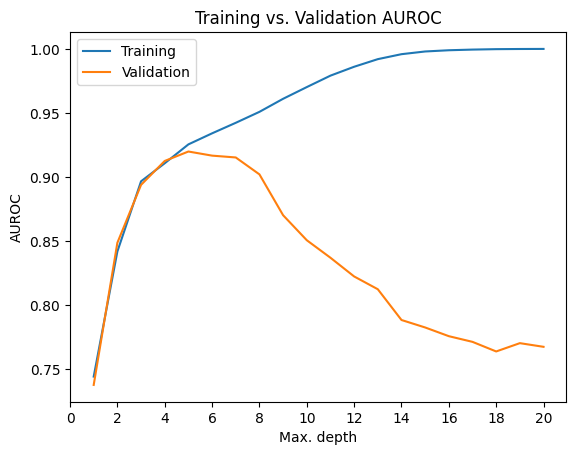

In [459]:
plt.figure()
plt.plot(auroc_df['Max depth'], auroc_df['AUROC train'])
plt.plot(auroc_df['Max depth'], auroc_df['AUROC validation'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

Найвище значення AUROC при `max_depth`= 5:

In [460]:
auroc_df[auroc_df['AUROC validation']==auroc_df['AUROC validation'].max()]

,Max depth,AUROC train,AUROC validation
4,5,0.925483,0.919912


Додатково дослідимо (незалежно від `max_depth`) параметр дерева `max_leaf_node` у проміжку значень  [20, 100]

In [461]:
# function to test settings: 1. train model, 2. predict, 3. calculate metric (AUROC)
def max_leaf_nodes_auroc(X_train, y_train, X_val, y_val, leaves):

    # setup and train model
    model = DecisionTreeClassifier(max_leaf_nodes=leaves, random_state=42)
    model.fit(X_train, y_train)

    # predict probabilities for train and validation data
    probs_train = model.predict_proba(X_train)
    probs_val = model.predict_proba(X_val)

    # Compute ROC curve for train and validation data
    fpr_train, tpr_train, _ = roc_curve(y_train, probs_train[:,1])
    fpr_val, tpr_val, _ = roc_curve(y_val, probs_val[:,1])

    # Compute AUROC for train and test data
    roc_auc_train = auc(fpr_train, tpr_train)
    roc_auc_val = auc(fpr_val, tpr_val)

    return {'Max leaves': leaves, 'AUROC train': roc_auc_train, 'AUROC validation': roc_auc_val}

In [462]:
auroc_leaves_df = pd.DataFrame([max_leaf_nodes_auroc(X_train, train_targets, X_val, val_targets, leaves) for leaves in range(20, 101)])

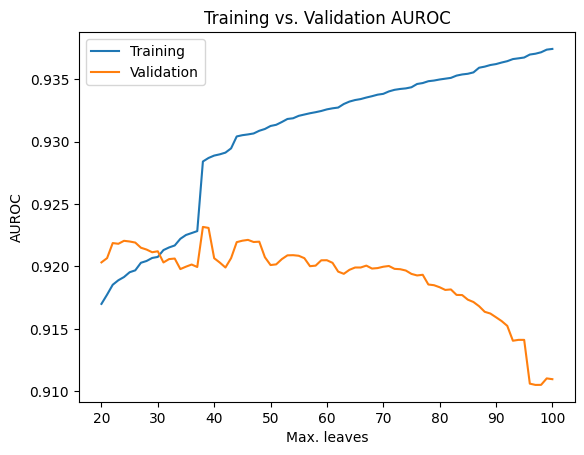

In [463]:
plt.figure()
plt.plot(auroc_leaves_df['Max leaves'], auroc_leaves_df['AUROC train'])
plt.plot(auroc_leaves_df['Max leaves'], auroc_leaves_df['AUROC validation'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(20,101, 10))
plt.xlabel('Max. leaves')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

Експеримент з найвищим значенням AUROC:

In [464]:
auroc_leaves_df[auroc_leaves_df['AUROC validation']==auroc_leaves_df['AUROC validation'].max()]

,Max leaves,AUROC train,AUROC validation
18,38,0.9284,0.92316


**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [465]:
# model for trying different settings of max_depth and max_leaf_nodes
model_depth5 = DecisionTreeClassifier(max_depth=5, random_state=42)

model_depth5.fit(X_train, train_targets)

# predicted probabilities for train data
train_depth5_probabilities = model_depth5.predict_proba(X_train)

# predicted probabilities for test data
val_depth5_probabilities = model_depth5.predict_proba(X_val)

In [466]:
# calculate AUROC for train data
compute_auroc(train_targets, train_depth5_probabilities[:,1], 'Training dataset');

AUROC for Training dataset: 0.92548


In [467]:
# calculate AUROC for validation data
compute_auroc(val_targets, val_depth5_probabilities[:,1], 'Validation dataset');

AUROC for Validation dataset: 0.91991


In [468]:
# load test data
test_raw_df = pd.read_csv('test.csv')
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [469]:
# preprocess test data
test_data = preprocess_new_data(test_raw_df,
                                input_cols=data['input_cols'],
                                numeric_cols=data['numeric_cols'],
                                categorical_cols=data['categorical_cols'],
                                encoder=data['encoder'],
                                scaler=data['scaler'],
                                scale_numeric=False)

In [470]:
test_data['X'].head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,584.0,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.0,1.0,0.0,0.0,1.0
1,551.0,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,1.0,0.0,0.0,0.0,1.0
2,706.0,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,1.0,0.0,0.0,0.0,1.0
3,717.0,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.0,0.0,1.0,0.0,1.0
4,592.0,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.0,0.0,1.0,0.0,1.0


In [471]:
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
8263,696.0,32.0,5.0,130627.66,1.0,1.0,1.0,86786.41,1.0,0.0,0.0,0.0,1.0
14199,632.0,32.0,4.0,119825.75,1.0,1.0,0.0,177737.04,0.0,1.0,0.0,1.0,0.0
1856,679.0,22.0,4.0,0.00,2.0,1.0,1.0,162599.54,1.0,0.0,0.0,1.0,0.0
3013,705.0,48.0,3.0,0.00,2.0,1.0,0.0,119814.25,1.0,0.0,0.0,0.0,1.0
8266,696.0,35.0,7.0,0.00,2.0,1.0,0.0,100423.88,1.0,0.0,0.0,1.0,0.0


In [472]:
# predicted probabilities for test data
test_depth5_probabilities = model_depth5.predict_proba(test_data['X'])

In [473]:
test_depth5_probabilities[0:10]

array([[0.78103837, 0.21896163],
       [0.97116737, 0.02883263],
       [0.97116737, 0.02883263],
       [0.24056604, 0.75943396],
       [0.97116737, 0.02883263],
       [0.79809725, 0.20190275],
       [0.99105081, 0.00894919],
       [0.97116737, 0.02883263],
       [0.98051948, 0.01948052],
       [0.99105081, 0.00894919]])

In [474]:
# add new column (Exited) with predicted probabilities of observation to refer to class 1

test_raw_df['Exited'] = np.round(test_depth5_probabilities[:,1],2)
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.22
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.03
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.03
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.76
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.03


In [475]:
# read from file
sample_submission_data = pd.read_csv('sample_submission.csv')
sample_submission_data.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [476]:
# add data into submission file (according to id)
sample_submission_data['Exited'] = sample_submission_data['id'].map(
    test_raw_df.set_index('id')['Exited']
)

In [477]:
sample_submission_data.head()

,id,Exited
0,15000,0.22
1,15001,0.03
2,15002,0.03
3,15003,0.76
4,15004,0.03


In [478]:
sample_submission_data.to_csv('sample_submission.csv', index=False)

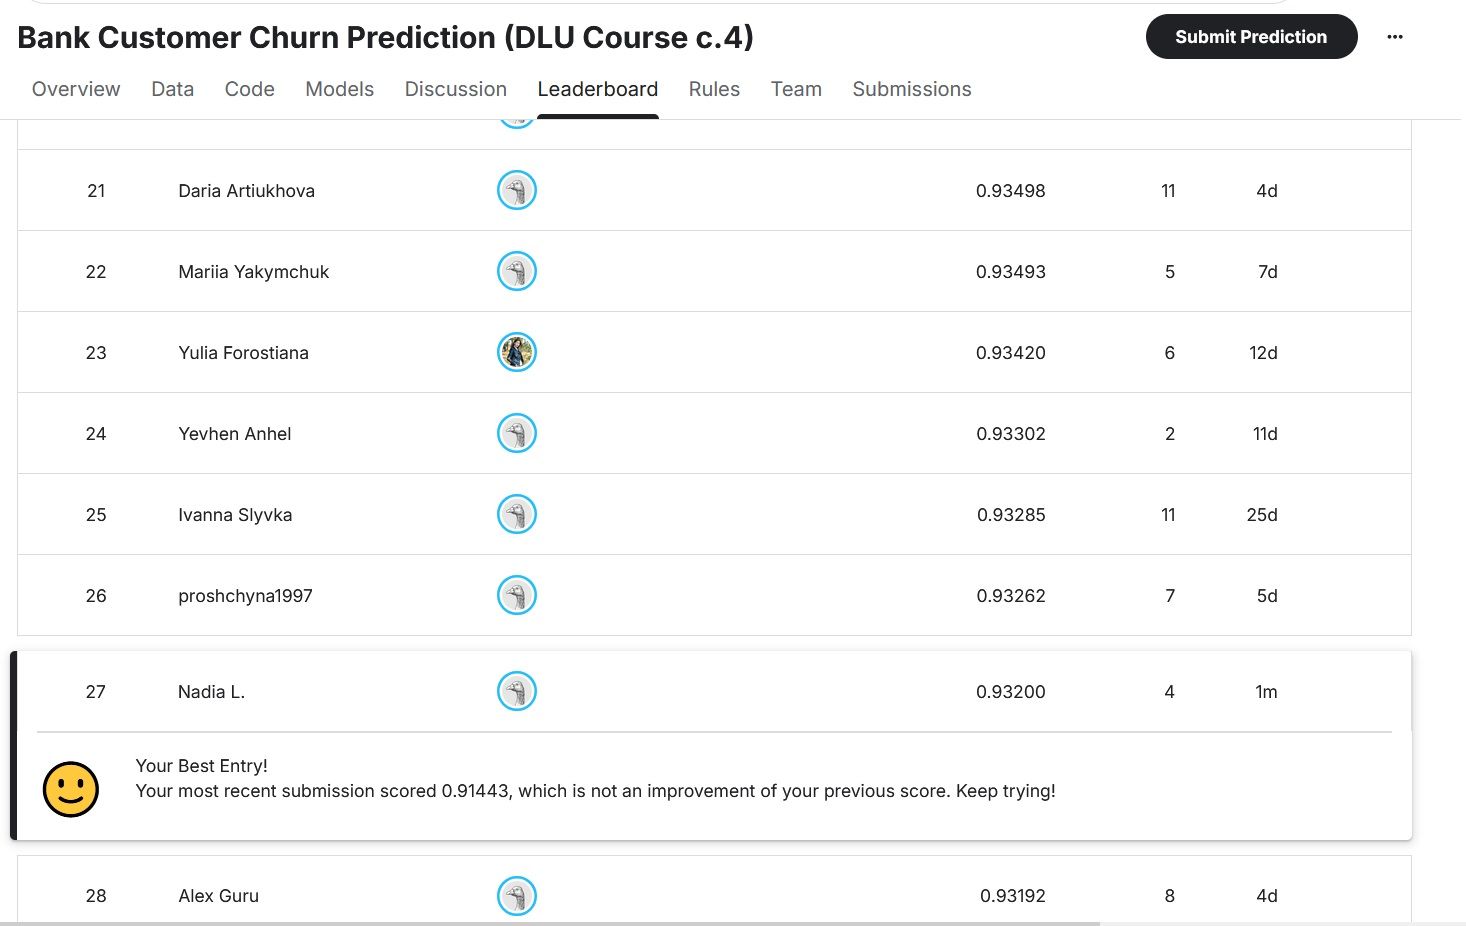